# PCA reconstruction accuracy: going back from PCs to the embedding

`pca_on_embeddings.ipynb` compressed each spot's embedding from 4608 numbers to a few hundred PC scores.
The question here is: **how much of the original embedding do we lose by doing that?**

To answer it, we go backwards:

1. Take a spot's PC scores (its position along PC1, PC2, ..., PCk)
2. Rebuild the embedding from them: `score1 × PC1 + score2 × PC2 + ... + scorek × PCk`, then undo the scaling
3. Compare the rebuilt embedding with the real one

In the StatQuest picture, this is the reverse of projecting. A point projected onto PC1 alone lands on the PC1 line.
Going back from that projection gives a point on the line, not the original point.
The distance between them (the `b` side of the triangle in the video) is the reconstruction error.
The more PCs we keep, the smaller that error.

We measure it on the **test spots**. The PCs were learned from the training spots, so the test spots show how well the PCs work on spots they've never seen.

**Needs:** the two files that `pca_on_embeddings.ipynb` saved in `outputs/`. The foundation model doesn't run again here.

In [14]:
import os
from pathlib import Path

if Path.cwd().stem == "notebooks":
    os.chdir(Path.cwd().parent)
print("Working folder:", os.getcwd())

Working folder: /Users/jk/JHU/BDD/Code


In [15]:
import glob
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [16]:
sample_id = "TENX95_random250"
SEED = 0

embedding_path = f"outputs/embeddings/{sample_id}_genbio-pathfm.npz"
pca_path = sorted(glob.glob(f"outputs/pca/{sample_id}_pca*.npz"))[0]

os.makedirs("outputs/reconstruction", exist_ok=True)

print("Embeddings file:", embedding_path)
print("PCA file:", pca_path)

Embeddings file: outputs/embeddings/TENX95_random250_genbio-pathfm.npz
PCA file: outputs/pca/TENX95_random250_pca200.npz


## 1. Load the embeddings and the same train/test split

The PCA file saved which barcodes were train and which were test.
We reuse that exact split so these results match the first notebook.

In [17]:
saved_emb = np.load(embedding_path, allow_pickle=True)
embeddings = saved_emb["embeddings"]
emb_barcodes = saved_emb["barcodes"]

saved_pca = np.load(pca_path, allow_pickle=True)
train_barcodes = saved_pca["train_barcodes"]
test_barcodes = saved_pca["test_barcodes"]

barcode_to_row = {}
for i, b in enumerate(emb_barcodes):
    barcode_to_row[b] = i

train_rows = [barcode_to_row[b] for b in train_barcodes]
test_rows = [barcode_to_row[b] for b in test_barcodes]

X_train = embeddings[train_rows]
X_test = embeddings[test_rows]

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (200, 4608)
X_test: (50, 4608)


## 2. Scale, then fit PCA with as many PCs as possible

Same as before: StandardScaler, then PCA, both fit on the training spots only.

This time we keep the **maximum** number of PCs, which is the number of training spots (PCA can't make more PCs than samples).
Then we can rebuild using only the first k of them, for any k we like, without refitting.

We do the reconstruction in the **scaled** space (every embedding number has mean 0 and SD 1).
That way each of the 4608 numbers counts equally in the error, just like they did in the PCA.

In [18]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

max_pcs = min(X_train.shape[0], X_train.shape[1])
pca = PCA(n_components=max_pcs, random_state=SEED)
pca.fit(X_train_scaled)

train_scores = pca.transform(X_train_scaled)
test_scores = pca.transform(X_test_scaled)

print("PCs fitted:", max_pcs)
print("Scores (train):", train_scores.shape)
print("Scores (test):", test_scores.shape)

PCs fitted: 200
Scores (train): (200, 200)
Scores (test): (50, 200)


## 3. A function that rebuilds embeddings from the first k PCs

```
rebuilt = scores[:, :k] @ components[:k] + mean
```

- `scores[:, :k]`: each spot's first k PC scores
- `components[:k]`: the first k PCs, each a recipe of 4608 loading scores (the unit vectors from the video)
- `@` is matrix multiplication: for each spot, it adds up score × PC over the k PCs
- `mean`: PCA centers the data first, so we add the center back

Then we measure how close `rebuilt` is to the real (scaled) embedding:

- **Variance explained (R²)** = 1 − (squared error) / (total squared spread around the training mean).
  1.0 means perfect, 0 means no better than guessing the average spot for everyone.
- **Cosine similarity**: whether the rebuilt vector points the same way as the real one, averaged over spots. 1.0 = same direction.

In [19]:
def rebuild(scores, k):
    return scores[:, :k] @ pca.components_[:k] + pca.mean_


def variance_explained(real, rebuilt):
    error = np.sum((real - rebuilt) ** 2)
    total = np.sum((real - pca.mean_) ** 2)
    return 1 - error / total


def mean_cosine(real, rebuilt):
    dot = np.sum(real * rebuilt, axis=1)
    length_real = np.linalg.norm(real, axis=1)
    length_rebuilt = np.linalg.norm(rebuilt, axis=1)
    return np.mean(dot / (length_real * length_rebuilt))

## 4. Reconstruction accuracy for different numbers of PCs

In [20]:
k_values = [1, 2, 5, 10, 20, 50, 100, 150, max_pcs]
k_values = sorted(set(k for k in k_values if k <= max_pcs))

train_r2 = []
test_r2 = []
test_cos = []

for k in k_values:
    rebuilt_train = rebuild(train_scores, k)
    rebuilt_test = rebuild(test_scores, k)

    train_r2.append(variance_explained(X_train_scaled, rebuilt_train))
    test_r2.append(variance_explained(X_test_scaled, rebuilt_test))
    test_cos.append(mean_cosine(X_test_scaled, rebuilt_test))

print(f"{'PCs':>5} {'train R2':>10} {'test R2':>10} {'test cosine':>12}")
for k, a, b, c in zip(k_values, train_r2, test_r2, test_cos):
    print(f"{k:>5} {a:>10.3f} {b:>10.3f} {c:>12.3f}")

  PCs   train R2    test R2  test cosine
    1      0.137      0.130        0.323
    2      0.224      0.208        0.426
    5      0.358      0.305        0.529
   10      0.477      0.392        0.615
   20      0.610      0.492        0.691
   50      0.784      0.582        0.758
  100      0.910      0.642        0.800
  150      0.970      0.671        0.820
  200      1.000      0.691        0.833


## 5. Plot: train vs test

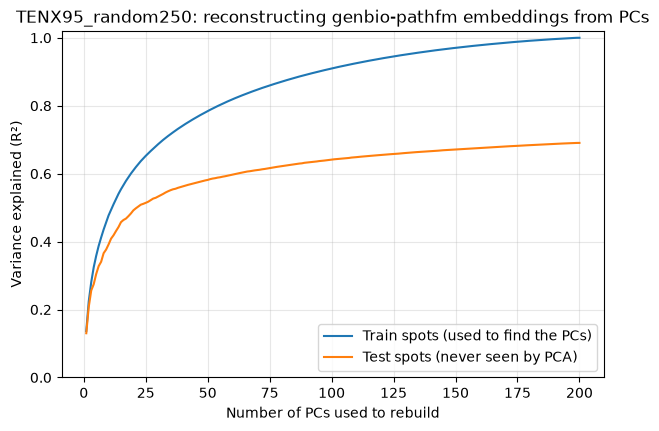

In [21]:
all_k = np.arange(1, max_pcs + 1)
train_curve = []
test_curve = []
for k in all_k:
    train_curve.append(variance_explained(X_train_scaled, rebuild(train_scores, k)))
    test_curve.append(variance_explained(X_test_scaled, rebuild(test_scores, k)))

plt.figure(figsize=(7, 4.5))
plt.plot(all_k, train_curve, label="Train spots (used to find the PCs)")
plt.plot(all_k, test_curve, label="Test spots (never seen by PCA)")
plt.xlabel("Number of PCs used to rebuild")
plt.ylabel("Variance explained (R²)")
plt.title(f"{sample_id}: reconstructing genbio-pathfm embeddings from PCs")
plt.ylim(0, 1.02)
plt.legend()
plt.grid(alpha=0.3)
plt.savefig(f"outputs/reconstruction/{sample_id}_reconstruction_curve.png", dpi=150, bbox_inches="tight")
plt.show()

### How to read this

- **Train curve:** it reaches 1.0 when k equals the number of training spots.
  With n spots there are only n directions of spread, so that many PCs can rebuild every training spot perfectly.
  This is also why train R² equals the cumulative scree curve from the first notebook.
- **Test curve:** this is the honest number. The gap between the two curves is information the training spots never showed the PCA.
  With only a few hundred training spots, the test curve can't reach 1.0,
  because test spots have directions of variation that weren't in the training set.
- With all spots (`MAX_SPOTS = None`, ~9,500 training spots) and HEST's 256 PCs, the two curves should be much closer.
  That's the setting where the "256 PCs keep X% of the embedding" number is meaningful to report.

## 6. One test spot: real vs rebuilt embedding

The first 100 of its 4608 (scaled) embedding numbers, with the rebuilt version from a few different k.

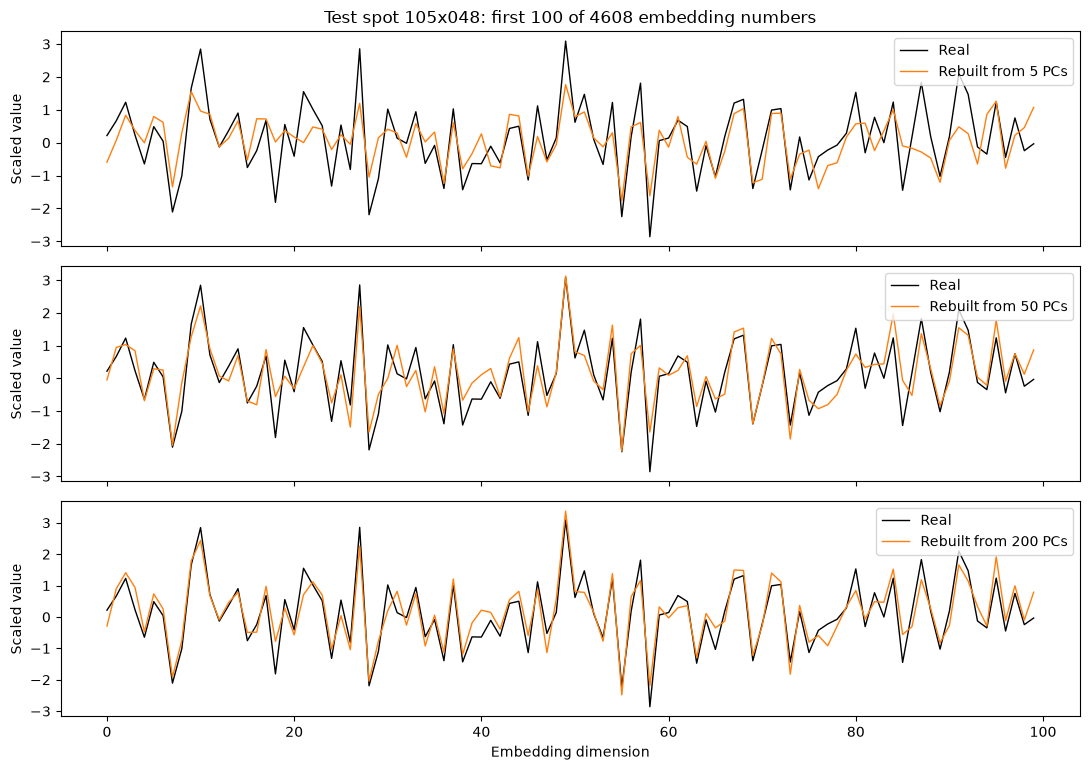

In [22]:
spot = 0
n_dims_to_show = 100
k_to_show = [5, 50, max_pcs]
k_to_show = [k for k in k_to_show if k <= max_pcs]

fig, axes = plt.subplots(len(k_to_show), 1, figsize=(11, 2.6 * len(k_to_show)), sharex=True)
if len(k_to_show) == 1:
    axes = [axes]

for ax, k in zip(axes, k_to_show):
    rebuilt_one = rebuild(test_scores[spot:spot + 1], k)[0]
    ax.plot(X_test_scaled[spot, :n_dims_to_show], label="Real", color="black", linewidth=1)
    ax.plot(rebuilt_one[:n_dims_to_show], label=f"Rebuilt from {k} PCs", color="tab:orange", linewidth=1)
    ax.set_ylabel("Scaled value")
    ax.legend(loc="upper right")

axes[-1].set_xlabel("Embedding dimension")
axes[0].set_title(f"Test spot {test_barcodes[spot]}: first {n_dims_to_show} of {X_test.shape[1]} embedding numbers")
plt.tight_layout()
plt.savefig(f"outputs/reconstruction/{sample_id}_one_spot.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Error per spot

Some spots may rebuild much worse than others, for example blank background patches or unusual tissue.
This shows each test spot's R² at the largest k.

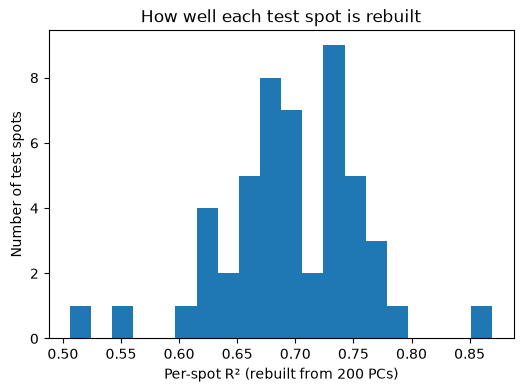

Worst-rebuilt test spots:
  079x016  R2 = 0.506
  077x064  R2 = 0.550
  054x021  R2 = 0.612
  082x055  R2 = 0.617
  045x084  R2 = 0.617


In [23]:
rebuilt_test = rebuild(test_scores, max_pcs)

spot_r2 = []
for i in range(len(X_test_scaled)):
    error = np.sum((X_test_scaled[i] - rebuilt_test[i]) ** 2)
    total = np.sum((X_test_scaled[i] - pca.mean_) ** 2)
    spot_r2.append(1 - error / total)
spot_r2 = np.array(spot_r2)

plt.figure(figsize=(6, 4))
plt.hist(spot_r2, bins=20)
plt.xlabel(f"Per-spot R² (rebuilt from {max_pcs} PCs)")
plt.ylabel("Number of test spots")
plt.title("How well each test spot is rebuilt")
plt.savefig(f"outputs/reconstruction/{sample_id}_per_spot_r2.png", dpi=150, bbox_inches="tight")
plt.show()

worst = np.argsort(spot_r2)[:5]
print("Worst-rebuilt test spots:")
for i in worst:
    print(f"  {test_barcodes[i]}  R2 = {spot_r2[i]:.3f}")

## 8. Learning curve: would more training spots help?

We pretend we had fewer training spots (25, 50, 100, 150, 200), fit the scaler + PCA on just those, and rebuild the **same 50 test spots** each time.

Picking which 50 (or 100...) spots is random, and a lucky or unlucky pick can change the result.
So for each size we repeat it 10 times with different random picks and take the average.

Two lines:
- **All PCs**: use every PC we can get (= number of training spots). This shows the most PCA can do with that much data.
- **20 PCs**: always use only 20 PCs. This shows whether the *first* PCs also get better with more data.

If the lines are still going up at 200, more spots should help.

In [24]:
train_sizes = [25, 50, 100, 150, len(X_train)]
n_repeats = 10
k_fixed = 20

rng = np.random.default_rng(SEED)

mean_r2_all = []
mean_r2_fixed = []
sd_r2_all = []

for n in train_sizes:
    r2_all_list = []
    r2_fixed_list = []

    for repeat in range(n_repeats):
        picked = rng.choice(len(X_train), size=n, replace=False)
        X_small = X_train[picked]

        small_scaler = StandardScaler()
        small_scaled = small_scaler.fit_transform(X_small)
        test_scaled = small_scaler.transform(X_test)

        n_pcs = min(n, X_small.shape[1])
        small_pca = PCA(n_components=n_pcs, random_state=SEED)
        small_pca.fit(small_scaled)
        scores = small_pca.transform(test_scaled)

        total = np.sum((test_scaled - small_pca.mean_) ** 2)

        rebuilt_all = scores @ small_pca.components_ + small_pca.mean_
        r2_all_list.append(1 - np.sum((test_scaled - rebuilt_all) ** 2) / total)

        k = min(k_fixed, n_pcs)
        rebuilt_fixed = scores[:, :k] @ small_pca.components_[:k] + small_pca.mean_
        r2_fixed_list.append(1 - np.sum((test_scaled - rebuilt_fixed) ** 2) / total)

    mean_r2_all.append(np.mean(r2_all_list))
    sd_r2_all.append(np.std(r2_all_list))
    mean_r2_fixed.append(np.mean(r2_fixed_list))

print(f"{'train spots':>12} {'test R2 (all PCs)':>18} {'test R2 (20 PCs)':>17}")
for n, a, s, f in zip(train_sizes, mean_r2_all, sd_r2_all, mean_r2_fixed):
    print(f"{n:>12} {a:>12.3f} ± {s:.3f} {f:>17.3f}")

 train spots  test R2 (all PCs)  test R2 (20 PCs)
          25        0.330 ± 0.015             0.317
          50        0.458 ± 0.007             0.386
         100        0.579 ± 0.005             0.445
         150        0.648 ± 0.003             0.476
         200        0.691 ± 0.000             0.492


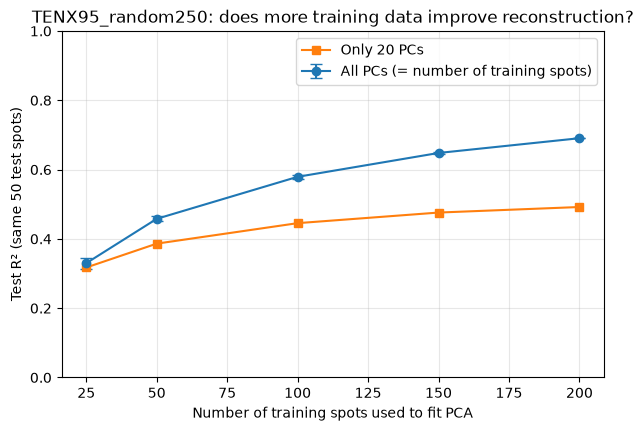

Going from 150 to 200 training spots raised test R² by 0.043


In [25]:
plt.figure(figsize=(7, 4.5))
plt.errorbar(train_sizes, mean_r2_all, yerr=sd_r2_all, marker="o", capsize=4, label="All PCs (= number of training spots)")
plt.plot(train_sizes, mean_r2_fixed, marker="s", label=f"Only {k_fixed} PCs")
plt.xlabel("Number of training spots used to fit PCA")
plt.ylabel("Test R² (same 50 test spots)")
plt.title(f"{sample_id}: does more training data improve reconstruction?")
plt.ylim(0, 1)
plt.grid(alpha=0.3)
plt.legend()
plt.savefig(f"outputs/reconstruction/{sample_id}_learning_curve.png", dpi=150, bbox_inches="tight")
plt.show()

gain = mean_r2_all[-1] - mean_r2_all[-2]
print(f"Going from {train_sizes[-2]} to {train_sizes[-1]} training spots raised test R² by {gain:.3f}")